In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from loguru import logger
import sys

In [3]:
logger.remove()
logger.add(sys.stderr, level="INFO")

1

In [4]:
import json
import random
import os
from tqdm import tqdm

from parser import ClevrParser
from program_executor import (
    programs_from_networkx,
    networkx_from_programs,
    set_scene,
    evaluate,
)
import numpy as np
from tqdm import tqdm

random.seed(42)

### Test abstraction

In [5]:
from abscon.abstraction import ClevrAbstractor
from abscon.concretization import ClevrConcretizer
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
from parser import ClevrParser
from tqdm import tqdm
from evaluation_utils import ClevrEvaluator, evaluate_graph_with_scene, evaluate_prediction
import nest_asyncio
nest_asyncio.apply()


In [6]:
folder = "results"
ground_truth_folder = "data"
approaches = ["greedy", "mv", "esc", "escf", "abscon",]
llms = ["gpt-4o-mini", "gpt-4o", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct", "qwq-32b"]

dataset = "clevr"
num_generations = 10

In [10]:
results = []

for approach in approaches:
    ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"
    
    result = {}
    result["approach"] = approach
    for llm in llms:
        print(f"Evaluating {approach} with {llm}...") 
        folder_path = f"{folder}/{llm}"
        evaluator = ClevrEvaluator(folder_path=folder_path, dataset_name=dataset)

        if approach == "greedy":
            metrics = evaluator.evaluate_greedy_result()
        elif approach == "esc": 
            metrics = evaluator.evaluate_execution_sc(num_generations)
        elif approach == "escf":
            metrics = evaluator.evaluate_execution_sc(num_generations, exclude_error=True)
        else:
            df = pd.read_csv(f"{folder_path}/{dataset}/results_{approach}_{num_generations}.csv")["0"].tolist()
            metrics = evaluator.evaluate_solutions(df)
        result[f"ACC_{llm}"] = metrics["accuracy"]
        result[f"SR_{llm}"] = metrics["success_rate"]
    results.append(result)

Evaluating greedy with gpt-4o-mini...
Evaluating greedy with gpt-4o...
Evaluating greedy with Meta-Llama-3.1-8B-Instruct...
Evaluating greedy with Meta-Llama-3.1-70B-Instruct...
Evaluating greedy with qwq-32b...
Evaluating mv with gpt-4o-mini...
Evaluating mv with gpt-4o...
Evaluating mv with Meta-Llama-3.1-8B-Instruct...
Evaluating mv with Meta-Llama-3.1-70B-Instruct...
Evaluating mv with qwq-32b...
Evaluating esc with gpt-4o-mini...
Evaluating esc with gpt-4o...
Evaluating esc with Meta-Llama-3.1-8B-Instruct...
Evaluating esc with Meta-Llama-3.1-70B-Instruct...
Evaluating esc with qwq-32b...
Evaluating escf with gpt-4o-mini...
Evaluating escf with gpt-4o...
Evaluating escf with Meta-Llama-3.1-8B-Instruct...
Evaluating escf with Meta-Llama-3.1-70B-Instruct...
Evaluating escf with qwq-32b...
Evaluating abscon with gpt-4o-mini...
Evaluating abscon with gpt-4o...
Evaluating abscon with Meta-Llama-3.1-8B-Instruct...
Evaluating abscon with Meta-Llama-3.1-70B-Instruct...
Evaluating abscon w

In [11]:
results_df = pd.DataFrame(results)
results_df[results_df.select_dtypes(include=['number']).columns] *= 100
# results_df = results_df[["approach", "success_rate", "accuracy"]]
# results_df.columns = ["approach", "SR", "ACC"]
print(results_df.round(2).to_markdown(index=False))

| approach   |   ACC_gpt-4o-mini |   SR_gpt-4o-mini |   ACC_gpt-4o |   SR_gpt-4o |   ACC_Meta-Llama-3.1-8B-Instruct |   SR_Meta-Llama-3.1-8B-Instruct |   ACC_Meta-Llama-3.1-70B-Instruct |   SR_Meta-Llama-3.1-70B-Instruct |   ACC_qwq-32b |   SR_qwq-32b |
|:-----------|------------------:|-----------------:|-------------:|------------:|---------------------------------:|--------------------------------:|----------------------------------:|---------------------------------:|--------------:|-------------:|
| greedy     |             39    |            45.67 |        65.33 |       71.33 |                            38    |                           48.33 |                             65    |                            72    |            98 |           99 |
| mv         |             21    |            66    |        51.67 |       77.33 |                            19    |                           86.33 |                             57.33 |                            90.67 |            76 |

In [ ]:
results_df
results_df_index = results_df.set_index("approach", inplace=False)

In [ ]:
diff = results_df_index.loc["abscon", :] - results_df_index.loc["greedy", :]
acc_diff = [value for key, value in diff.items() if "ACC" in key]
print(f"Min improvement: {min(acc_diff)}, max improvement: {max(acc_diff)}, average improvement: {np.mean(acc_diff)}")

In [ ]:
diff = results_df_index.loc["abscon", :] - results_df_index.loc["escf", :]
acc_diff = [value for key, value in diff.items() if "ACC" in key]
print(f"Min improvement: {min(acc_diff)}, max improvement: {max(acc_diff)}, average improvement: {np.mean(acc_diff)}")

## RQ2

In [7]:
def get_result(dataset, llms, num_generation, approaches, folder):
    result = {}
    for approach in approaches:
        result[approach] = {}
        for llm in llms:
            print(f"Evaluating {approach} with {llm}...")
            folder_path = f"{folder}/{llm}"
            evaluator = ClevrEvaluator(
                folder_path=folder_path,
                dataset_name=dataset,
            )

            if approach == "greedy":
                metrics = evaluator.evaluate_greedy_result()
            elif approach == "esc":
                metrics = evaluator.evaluate_execution_sc(num_generation)
            elif approach == "escf":
                metrics = evaluator.evaluate_execution_sc(num_generation, exclude_error=True)
            elif approach == "best":
                metrics = evaluator.evaluate_execution_sc(
                    num_generation, exclude_error=True, best_answer=True
                )
            else:
                df = pd.read_csv(
                    f"{folder_path}/{dataset}/results_{approach}_{num_generation}.csv"
                )["0"].tolist()
                metrics = evaluator.evaluate_solutions(df)
                print(metrics)
            result[approach][llm] = metrics
    return result

In [8]:
from tqdm.notebook import tqdm
import pandas as pd
from evaluation_utils import ClevrEvaluator
import numpy as np
import nest_asyncio
nest_asyncio.apply()

In [13]:
folder = "results"
ground_truth_folder = "data"
approaches = ["mv", "greedy", "abscon", "esc", "escf", "best"]
llms = ["Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"]# ["Meta-Llama-3.1-70B-Instruct"]

dataset = "clevr"
num_generations = range(1, 21)

In [15]:
results = []

for num_generation in tqdm(num_generations):
    result = get_result(dataset, llms, num_generation, approaches, folder)
    results.append(result)

  0%|          | 0/20 [00:00<?, ?it/s]

{'success_rate': 0.44333333333333336, 'accuracy': 0.35333333333333333}
{'success_rate': 0.73, 'accuracy': 0.6766666666666666}
{'success_rate': 0.4833333333333333, 'accuracy': 0.38}
{'success_rate': 0.72, 'accuracy': 0.65}
{'success_rate': 0.7433333333333334, 'accuracy': 0.4}
{'success_rate': 0.9566666666666667, 'accuracy': 0.6766666666666666}
{'success_rate': 0.44333333333333336, 'accuracy': 0.35333333333333333}
{'success_rate': 0.73, 'accuracy': 0.6766666666666666}
{'success_rate': 0.44333333333333336, 'accuracy': 0.35333333333333333}
{'success_rate': 0.73, 'accuracy': 0.6766666666666666}
{'success_rate': 0.44333333333333336, 'accuracy': 0.35333333333333333}
{'success_rate': 0.73, 'accuracy': 0.6766666666666666}
{'success_rate': 0.7566666666666666, 'accuracy': 0.12}
{'success_rate': 0.85, 'accuracy': 0.41333333333333333}
{'success_rate': 0.4833333333333333, 'accuracy': 0.38}
{'success_rate': 0.72, 'accuracy': 0.65}
{'success_rate': 0.9266666666666666, 'accuracy': 0.5366666666666666}
{

In [28]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib
plt.style.use(['science', "ieee"])

models = ["Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"] #["Meta-Llama-3.1-70B-Instruct"]
model_names = ["Llama3.1 8b", "Llama3.1 70b"]
approaches = ["escf", "abscon", "best", "esc", "greedy"]
approach_names = ["ESC-F", "AbsCon", "Best", "Median", "Direct"]
lines = ["-", "-", "--", "--", "-"]
markers = ['*', '.', '^', 'v', '']

colors = [[33, 25, 24], [195, 56, 40], [71, 133, 90] , [71, 133, 90],  [231, 189, 57]]
colors = [[c / 255 for c in color] for color in colors]

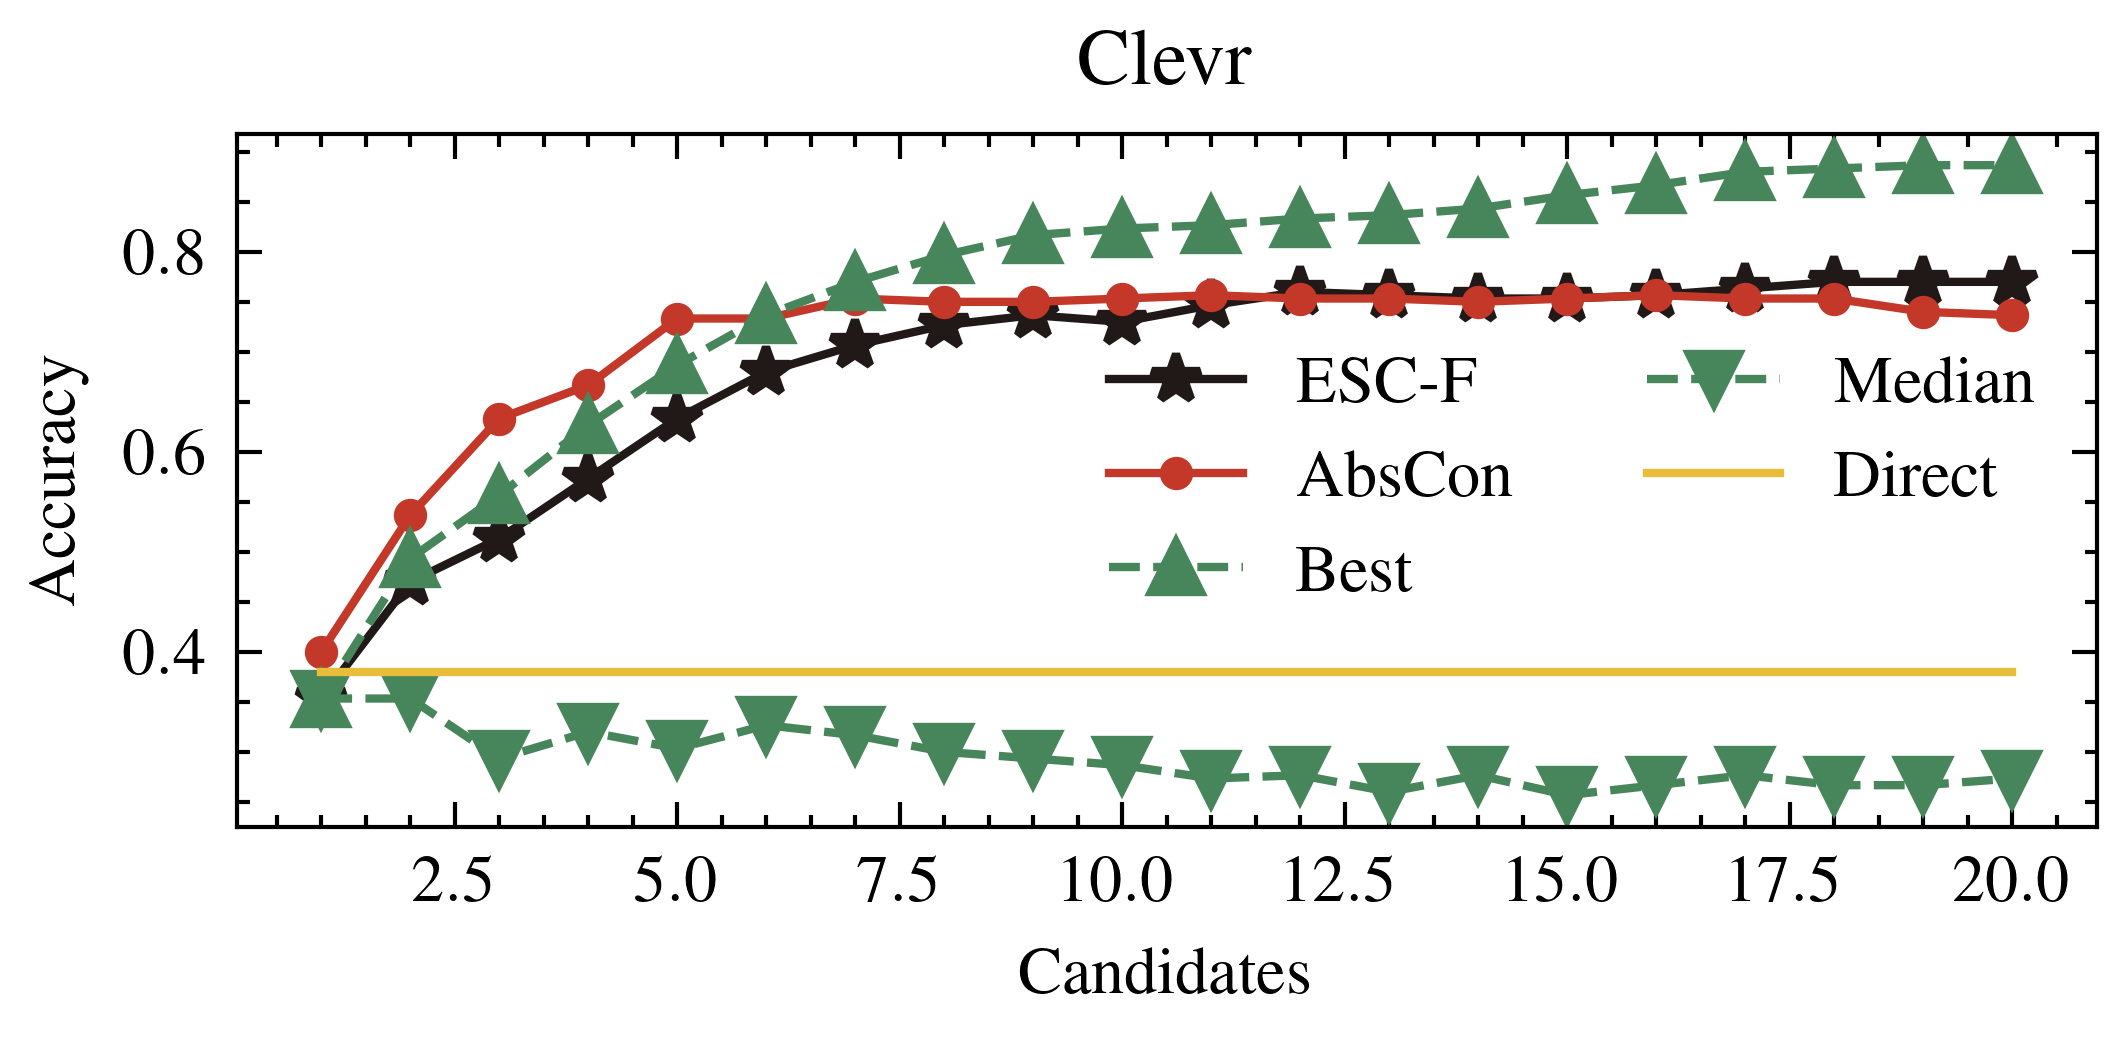

In [20]:
plt.figure(figsize=(4,1.5))
metric = "accuracy"
x = num_generations
f1_values = []
for i, llm in enumerate(models):
    for j, approach in enumerate(approaches):
        values = [data[approach][llm][metric] for data in results]
        if approach in ["escf", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
plt.legend(shadow=True, ncol=2)
plt.title("Clevr")
plt.ylabel("Accuracy")
plt.xlabel("Candidates")
# plt.savefig("Clevr.png", dpi=300)
plt.show()        

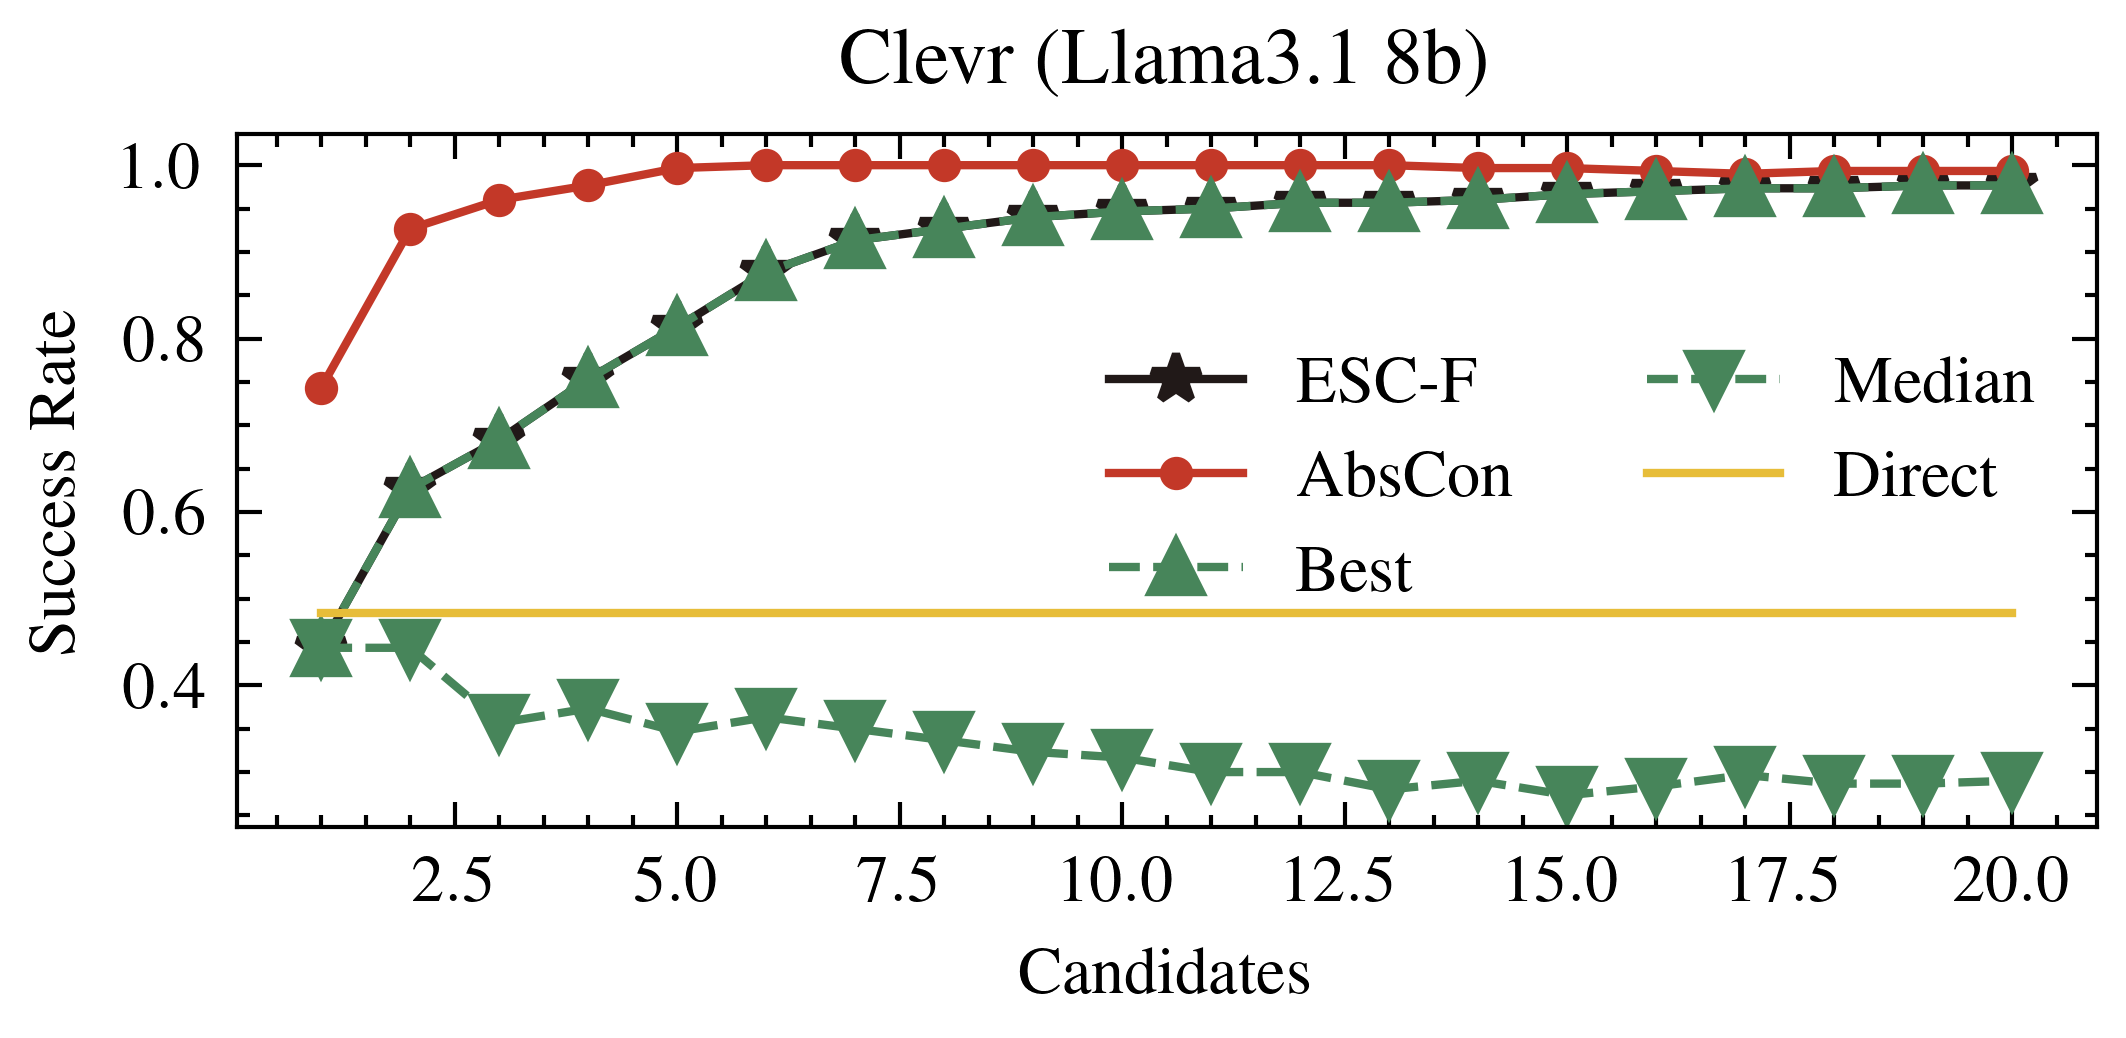

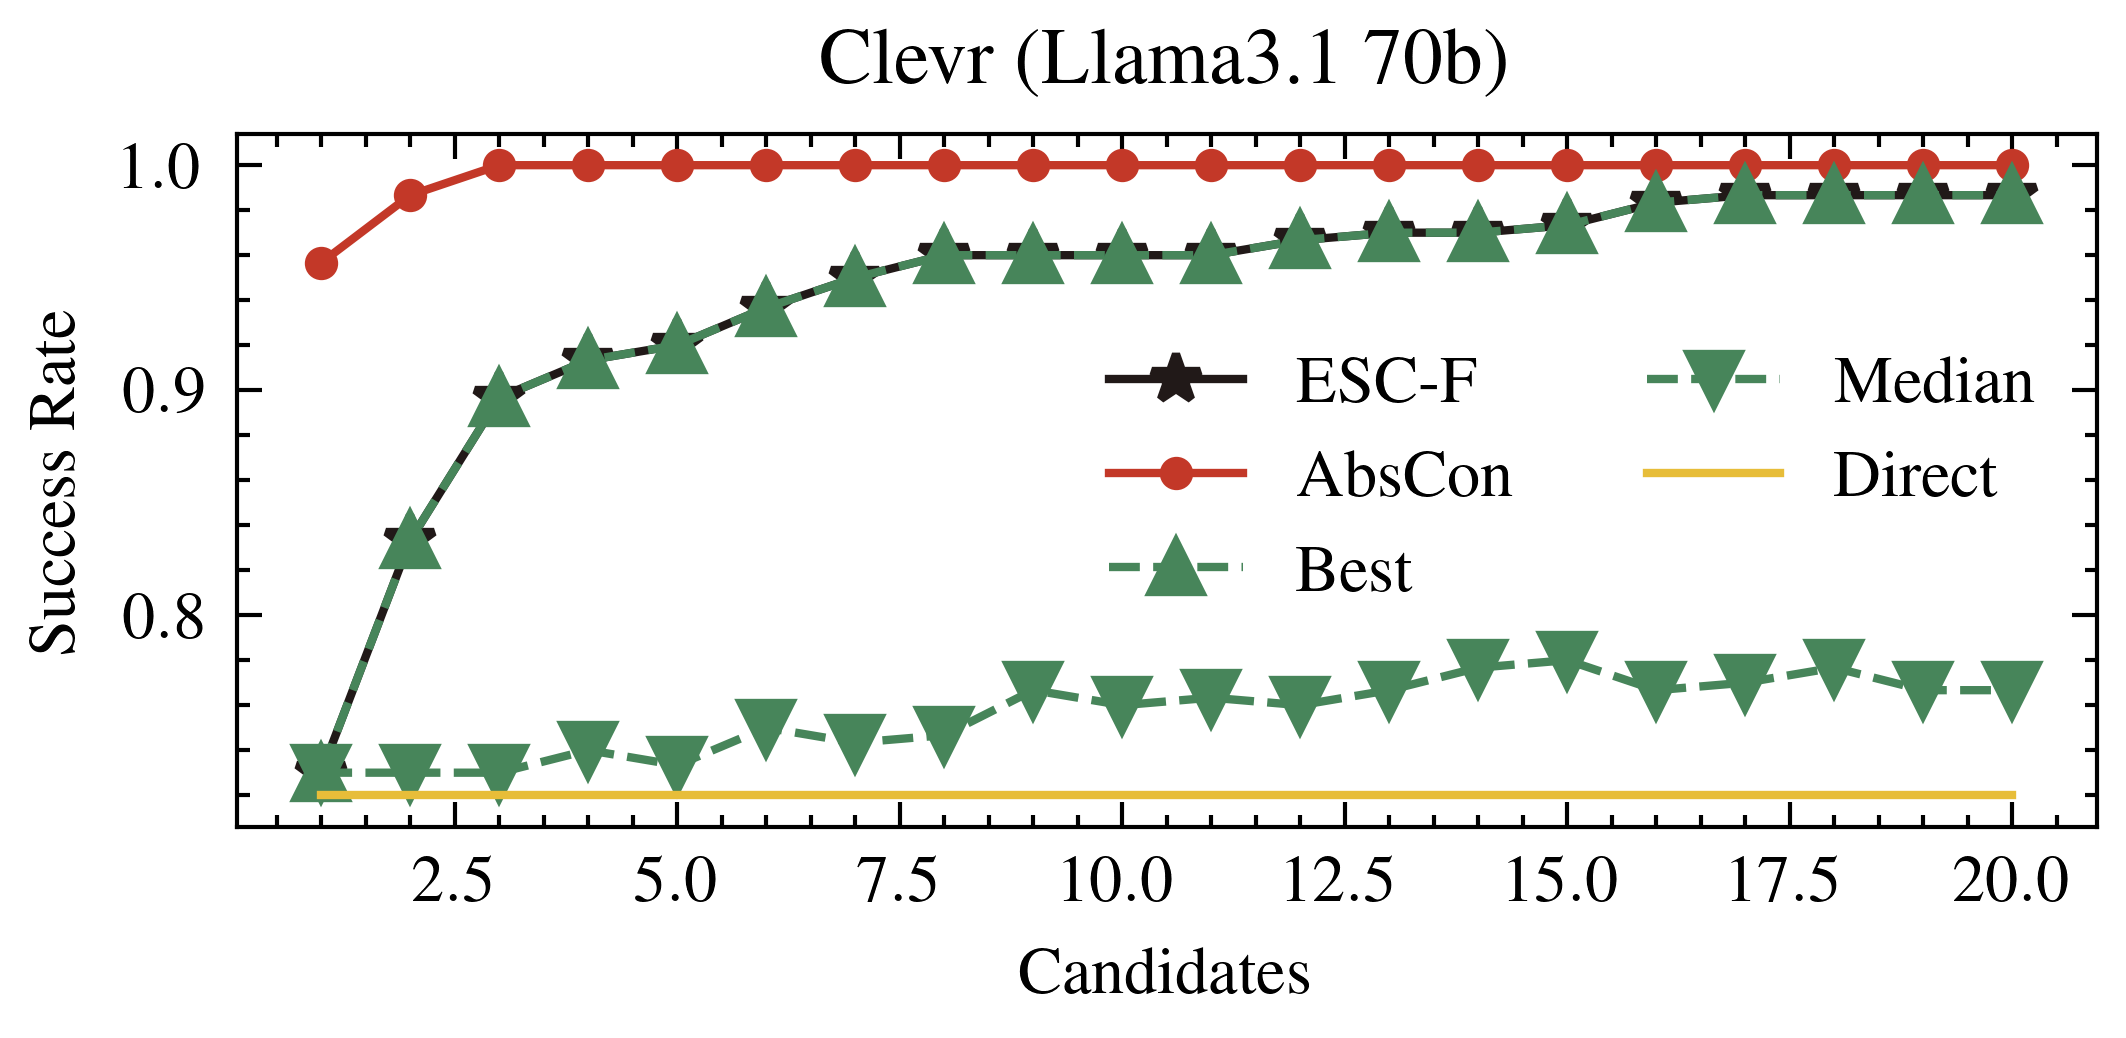

In [29]:
metric = "success_rate"
x = num_generations
f1_values = []
for i, llm in enumerate(models):
    plt.figure(figsize=(4,1.5))
    for j, approach in enumerate(approaches):
        values = [data[approach][llm][metric] for data in results]
        if approach in ["escf", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
    plt.legend(shadow=True, ncol=2)
    plt.title(f"Clevr ({model_names[i]})")
    plt.ylabel("Success Rate")
    plt.xlabel("Candidates")
    # plt.savefig("Clevr.png", dpi=300)
    plt.show()        

## RQ3: Impact of Temperature

In [13]:
def get_result_temperature(dataset, llms, num_generation, temperatures, folder):
    result = {}
    for temperature in temperatures:
        result[temperature] = {}
        for llm in llms:
            print(f"Evaluating {temperature} with {llm}...")
            folder_path = f"{folder}/temperature/{temperature}/{llm}/{dataset}"
            evaluator = ClevrEvaluator(
                folder_path=folder_path,
                dataset_name=dataset,
            )
            df = pd.read_csv(
                f"{folder_path}/results_abscon_{num_generation}.csv"
            )["0"].tolist()
            metrics = evaluator.evaluate_solutions(df)
            result[temperature][llm] = metrics
    return result

In [14]:
temperatures = ["0.1", "0.4", "0.7", "1.0"]
num_generations = range(1, 11)
llms = ["llama-3.1-8b-instruct", "llama-3.1-70b-instruct"]
dataset = "clevr"

results = []

for num_generation in tqdm(num_generations):
    result = get_result_temperature(dataset, llms, num_generation, temperatures, folder)
    results.append(result)

  0%|          | 0/10 [00:00<?, ?it/s]

Evaluating 0.1 with llama-3.1-8b-instruct...
Evaluating 0.1 with llama-3.1-70b-instruct...
Evaluating 0.4 with llama-3.1-8b-instruct...
Evaluating 0.4 with llama-3.1-70b-instruct...
Evaluating 0.7 with llama-3.1-8b-instruct...
Evaluating 0.7 with llama-3.1-70b-instruct...
Evaluating 1.0 with llama-3.1-8b-instruct...
Evaluating 1.0 with llama-3.1-70b-instruct...
Evaluating 0.1 with llama-3.1-8b-instruct...
Evaluating 0.1 with llama-3.1-70b-instruct...
Evaluating 0.4 with llama-3.1-8b-instruct...
Evaluating 0.4 with llama-3.1-70b-instruct...
Evaluating 0.7 with llama-3.1-8b-instruct...
Evaluating 0.7 with llama-3.1-70b-instruct...
Evaluating 1.0 with llama-3.1-8b-instruct...
Evaluating 1.0 with llama-3.1-70b-instruct...
Evaluating 0.1 with llama-3.1-8b-instruct...
Evaluating 0.1 with llama-3.1-70b-instruct...
Evaluating 0.4 with llama-3.1-8b-instruct...
Evaluating 0.4 with llama-3.1-70b-instruct...
Evaluating 0.7 with llama-3.1-8b-instruct...
Evaluating 0.7 with llama-3.1-70b-instruct...

In [15]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib
plt.style.use(['science', "ieee"])

models = ["llama-3.1-8b-instruct", "llama-3.1-70b-instruct"]
model_names = ["Llama3.1 8b", "Llama3.1 70b"]
temperatures = ["0.1", "0.4", "0.7", "1.0"]
lines = ["-", "-", "--", "--", "-"]
markers = ['*', '.', '^', 'v', '']

colors = [[33, 25, 24], [195, 56, 40], [71, 133, 90] ,  [231, 189, 57]]
colors = [[c / 255 for c in color] for color in colors]

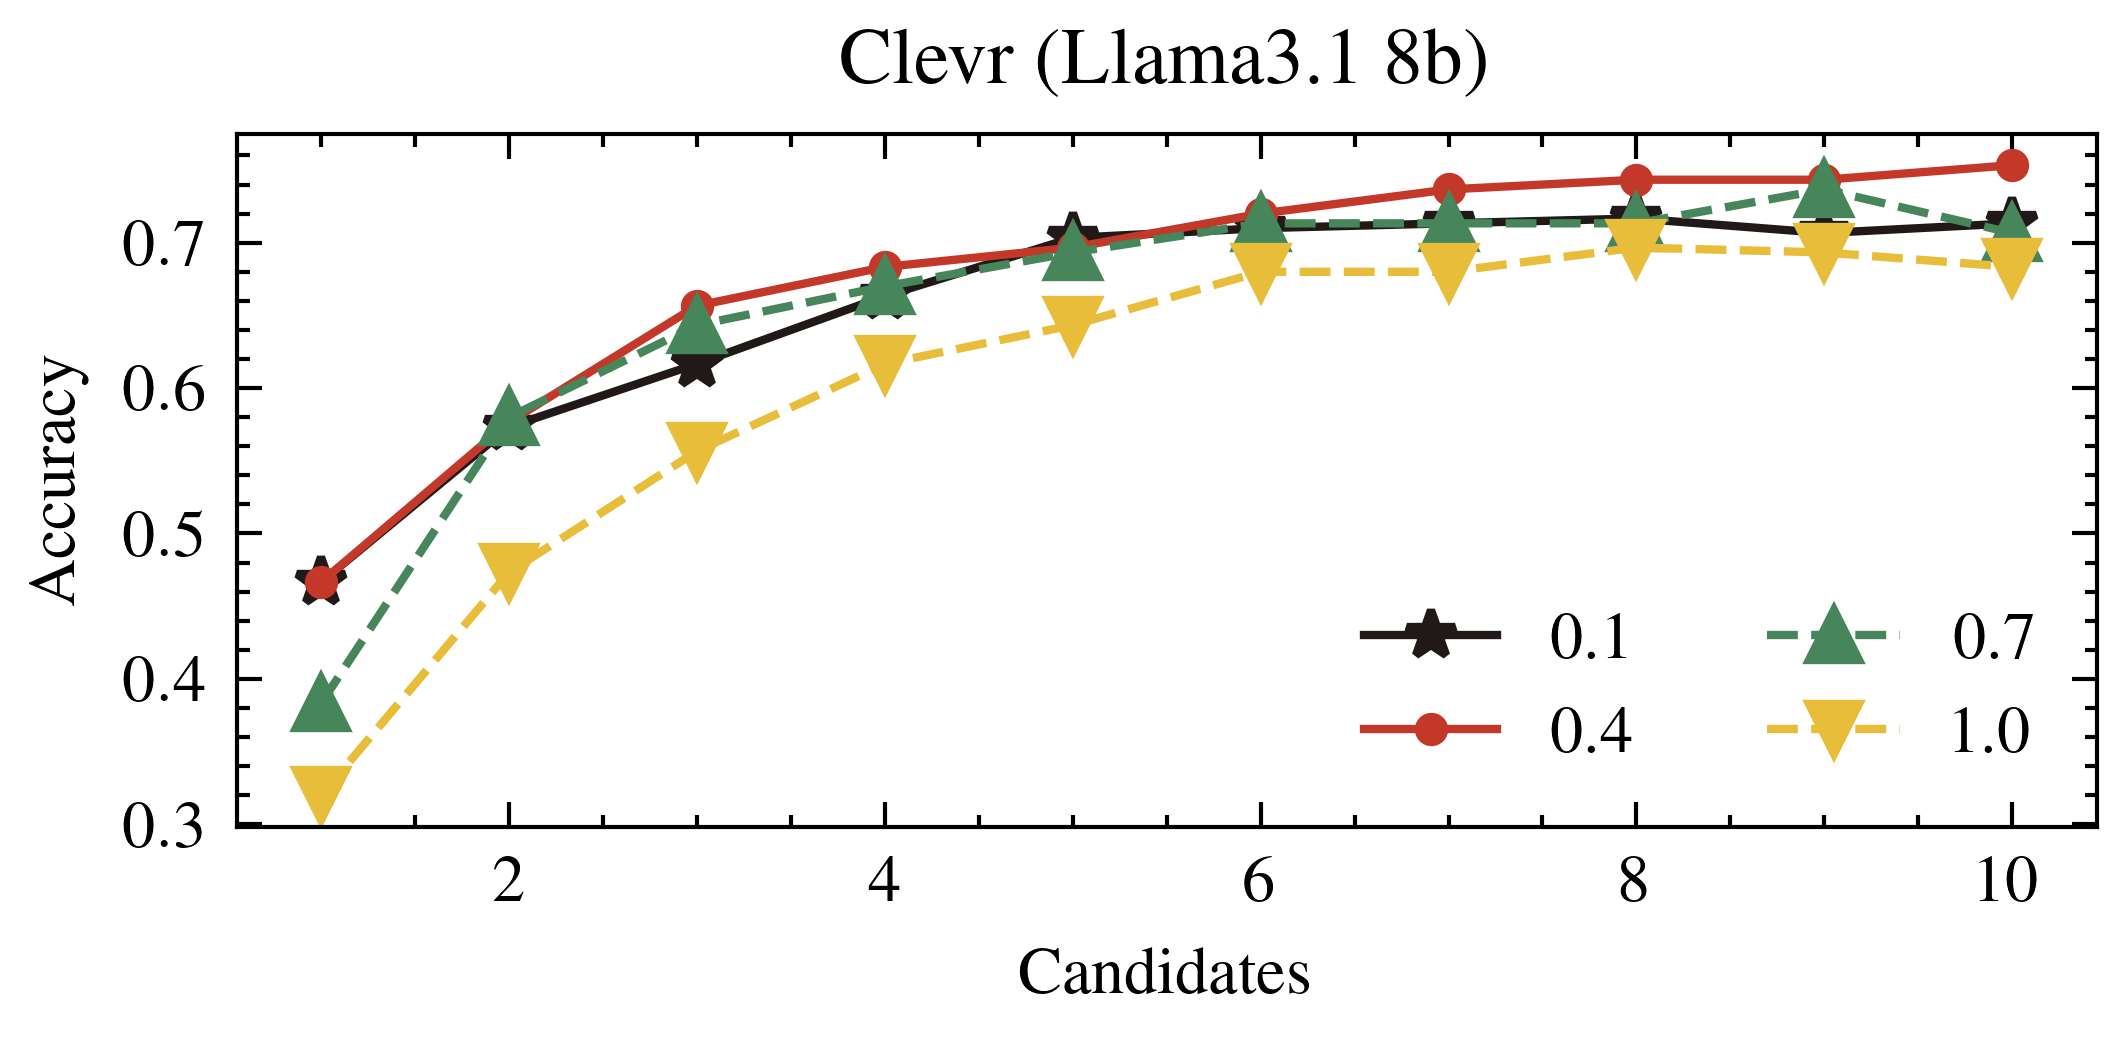

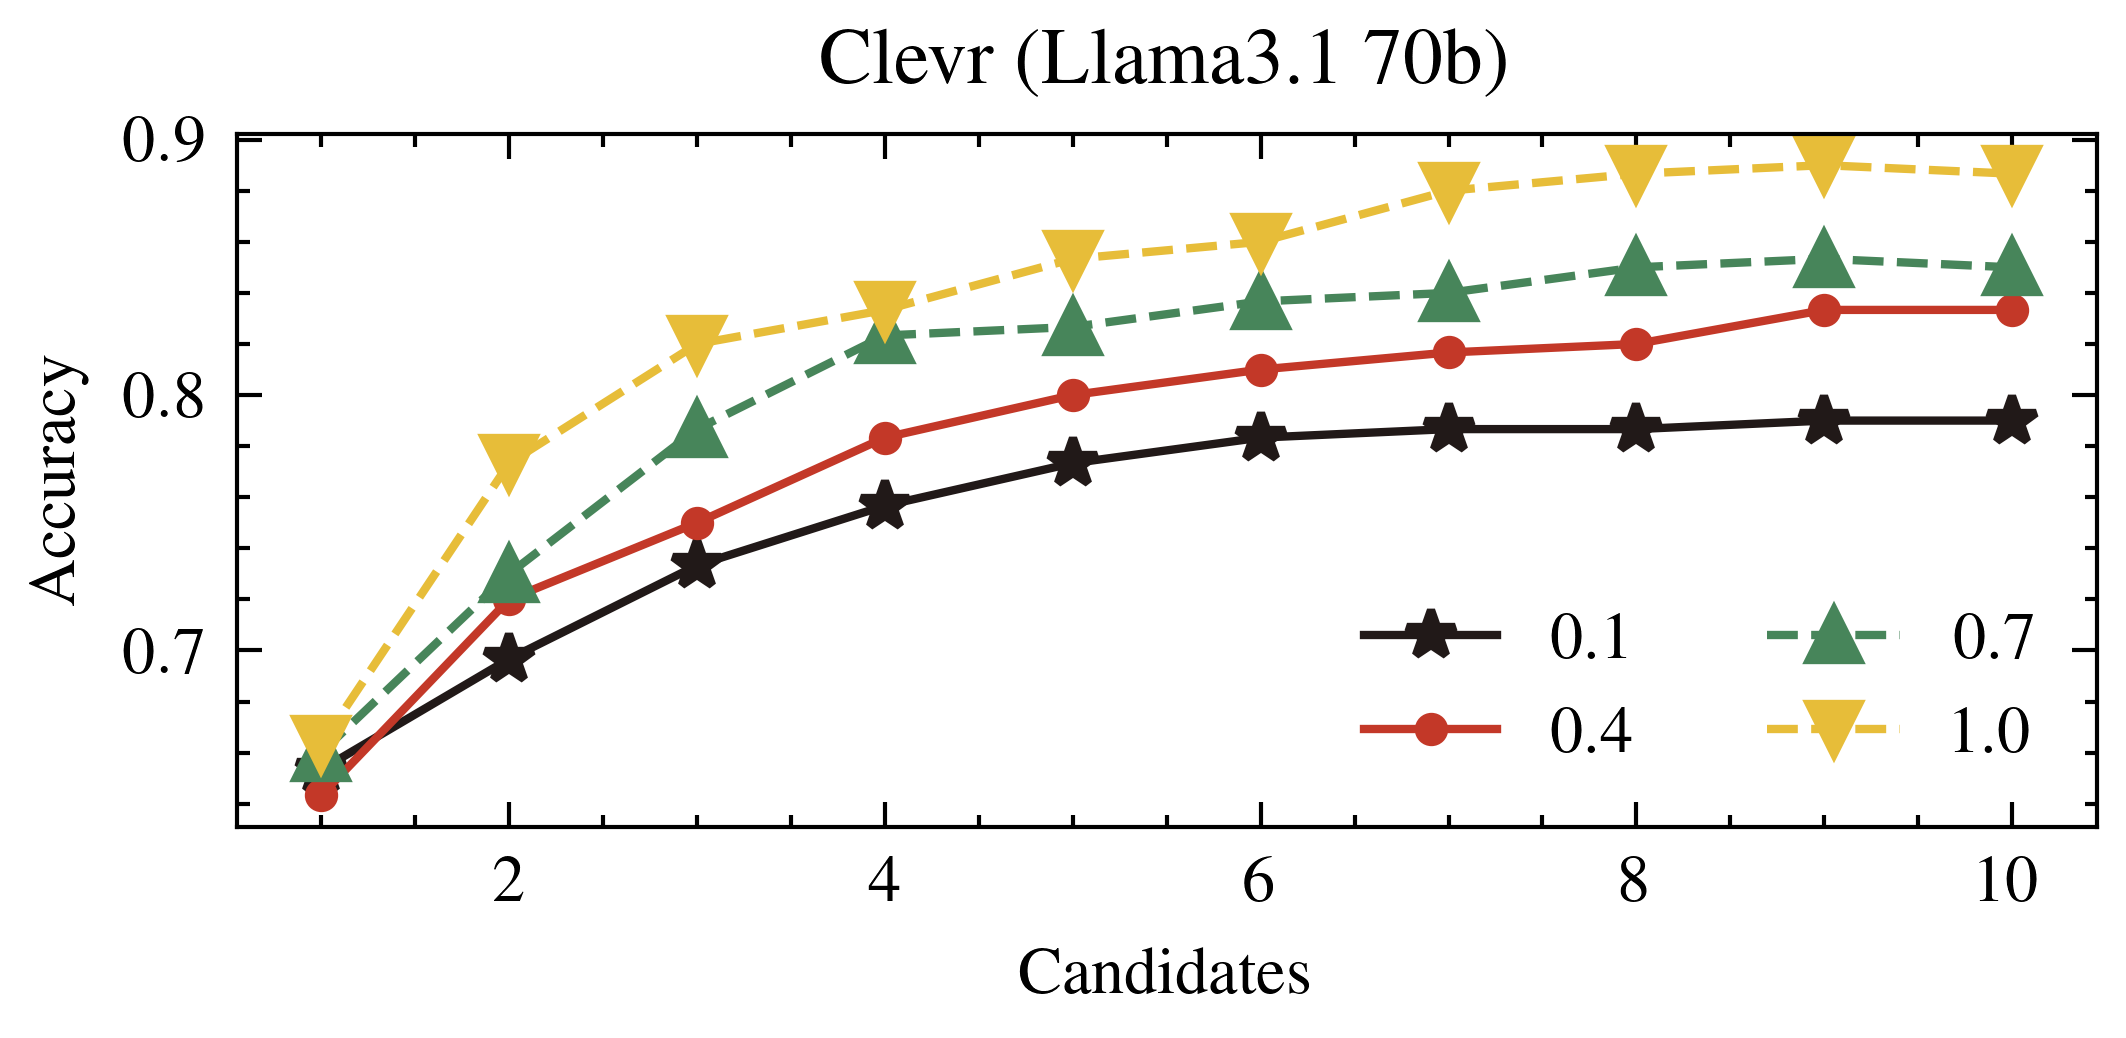

In [20]:
metric = "accuracy"
x = num_generations
for i, llm in enumerate(models):
    plt.figure(figsize=(4,1.5))
    for j, temperature in enumerate(temperatures):
        values = [data[temperature][llm][metric] for data in results]
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=temperature, marker=markers[j])
    plt.legend(shadow=True, ncol=2)
    plt.title(f"Clevr ({model_names[i]})")
    plt.ylabel("Accuracy")
    plt.xlabel("Candidates")
    # plt.savefig("Clevr.png", dpi=300)
    plt.show()        